# Bongor-N'Djamena reanalysis
<!-- markdownlint-disable MD013 -->
Comparison of reanalysis betwee Bongor and N'Djamena stations

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [103]:
import matplotlib.pyplot as plt
import ocha_stratus as stratus
import pandas as pd

from src.datasources import glofas
from src.constants import *

In [63]:
# df_n = glofas.load_reanalysis(local=True)
df_n = glofas.load_glofas_reanalysis("ndjamena")

In [64]:
df_n

,time,dis24
0,1979-01-01,454.390625
1,1979-01-02,448.234375
2,1979-01-03,442.218750
3,1979-01-04,436.328125
4,1979-01-05,430.562500
...,...,...
16797,2024-12-27,180.539062
16798,2024-12-28,176.726562
16799,2024-12-29,173.054688
16800,2024-12-30,169.460938


In [65]:
df_b = glofas.load_glofas_reanalysis("bongor")

In [66]:
df_b

,time,dis24
0,1979-01-01,71.515625
1,1979-01-02,70.484375
2,1979-01-03,69.484375
3,1979-01-04,68.500000
4,1979-01-05,67.546875
...,...,...
16797,2024-12-27,27.203125
16798,2024-12-28,26.523438
16799,2024-12-29,25.859375
16800,2024-12-30,25.242188


In [67]:
df_compare = df_b.merge(df_n, on="time", suffixes=("_b", "_n"))

<Axes: xlabel='time'>

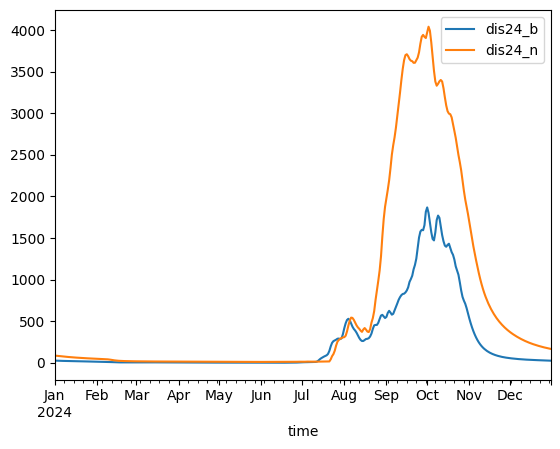

In [289]:
df_compare[df_compare["time"].dt.year == 2024].plot(x="time")

In [68]:
df_peaks = (
    df_compare.groupby(df_compare["time"].dt.year)
    .max()
    .drop(columns="time")
    .reset_index()
)

In [69]:
df_peaks

,time,dis24_b,dis24_n
0,1979,2221.429688,6702.617188
1,1980,2424.890625,10311.976562
2,1981,2846.054688,9836.851562
3,1982,2015.781250,5310.609375
4,1983,1661.101562,4465.054688
5,1984,1181.796875,2902.968750
6,1985,2563.015625,8262.921875
7,1986,1816.671875,4657.296875
8,1987,2071.593750,4840.187500
9,1988,3238.093750,9754.734375


In [70]:
df_peaks.corr()

,time,dis24_b,dis24_n
time,1.000000,-0.356604,-0.550891
dis24_b,-0.356604,1.000000,0.899206
dis24_n,-0.550891,0.899206,1.000000


<Axes: xlabel='dis24_b', ylabel='dis24_n'>

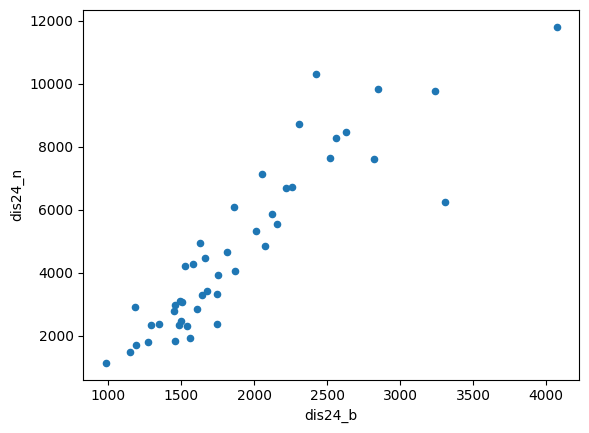

In [71]:
df_peaks.plot.scatter(x="dis24_b", y="dis24_n")

<Axes: xlabel='time'>

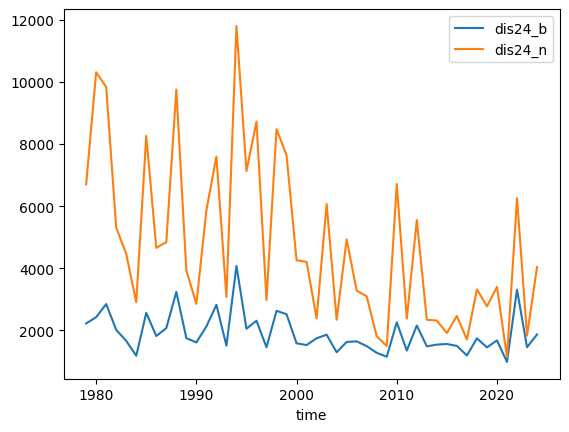

In [81]:
df_peaks.plot(x="time")

Text(0, 0.5, "N'Djamena")

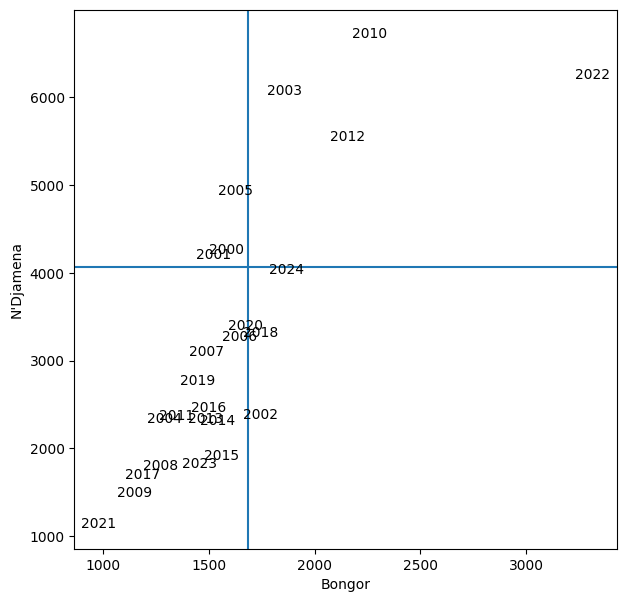

In [79]:
fig, ax = plt.subplots(figsize=(7, 7))

df_plot = df_peaks[df_peaks["time"] >= 2000]

df_plot.plot(x="dis24_b", y="dis24_n", linewidth=0, ax=ax, legend=False)

for year, row in df_plot.set_index("time").iterrows():
    ax.annotate(
        year, (row["dis24_b"], row["dis24_n"]), ha="center", va="center"
    )

rp = 3.5
x_thresh = df_plot["dis24_b"].quantile(1 - 1 / rp)
y_thresh = df_plot["dis24_n"].quantile(1 - 1 / rp)

ax.axhline(y_thresh)
ax.axvline(x_thresh)

ax.set_xlabel("Bongor")
ax.set_ylabel("N'Djamena")

In [267]:
query = f"""
SELECT pcode, valid_date, mean
FROM public.floodscan
WHERE pcode IN {(NDJAMENA1, MAYOKEBBIEST1)}
AND band = 'SFED'
"""
df_fs = pd.read_sql(
    query, stratus.get_engine(stage="prod"), parse_dates=["valid_date"]
)

In [281]:
def calculate_one_group_rp(group, col_name: str = "q", ascending: bool = True):
    """Calculate the empirical RP for a single group.

    Parameters
    ----------
    group : pd.DataFrame
        The group for which to calculate the RP.
    col_name : str, optional
        The name of the column for which to calculate the RP, by default "q".
    ascending : bool, optional
        Whether to rank the column in ascending order, by default True.
        Should be False for cases where a high number is severe
        (e.g. precipitation for flooding), and True for cases where a low
        number is severe (e.g. precipitation for drought).

    Returns
    -------
    pd.DataFrame
        The input group with the RP columns added.
    """
    group[f"{col_name}_rank"] = group[col_name].rank(ascending=ascending)
    group[f"{col_name}_rp"] = (len(group) + 1) / group[f"{col_name}_rank"]
    return group

In [412]:
# df_peaks_recent = df_peaks[df_peaks["time"] >= 2000].copy()
df_peaks_recent = df_peaks[
    (df_peaks["time"] >= 2003) & (df_peaks["time"] <= 2024)
].copy()

In [413]:
total_years = df_peaks_recent["time"].nunique()
target_rp = 3.5
target_year_count = int((total_years + 1) / target_rp)
actual_rp = (total_years + 1) / target_year_count
target_year_count, actual_rp

(6, 3.8333333333333335)

In [414]:
for x in ["b", "n"]:
    df_peaks_recent = calculate_one_group_rp(
        df_peaks_recent, f"dis24_{x}", ascending=False
    )

In [415]:
df_peaks_recent["min_rp"] = df_peaks_recent[
    [f"dis24_{x}_rp" for x in ["b", "n"]]
].min(axis=1)
df_peaks_recent["max_rp"] = df_peaks_recent[
    [f"dis24_{x}_rp" for x in ["b", "n"]]
].max(axis=1)

In [416]:
def determine_trig(col):
    thresh = df_peaks_recent.sort_values(col, ascending=False).iloc[
        target_year_count - 1
    ][col]
    return df_peaks_recent[col] >= thresh

In [417]:
df_peaks_recent["or_trig"] = determine_trig("max_rp")
df_peaks_recent["and_trig"] = determine_trig("min_rp")
df_peaks_recent["n_only_trig"] = determine_trig("dis24_n_rp")
df_peaks_recent["b_only_trig"] = determine_trig("dis24_b_rp")

In [418]:
df_peaks_recent["indep_trig"] = df_peaks_recent[
    ["b_only_trig", "n_only_trig"]
].any(axis=1)

In [419]:
df_peaks_recent.sort_values("dis24_n_rp", ascending=False)

,time,dis24_b,dis24_n,dis24_b_rank,dis24_b_rp,dis24_n_rank,dis24_n_rp,min_rp,max_rp,or_trig,and_trig,n_only_trig,b_only_trig,indep_trig
31,2010,2258.960938,6714.945312,2.0,11.500000,1.0,23.000000,11.500000,23.000000,True,True,True,True,True
43,2022,3311.179688,6254.054688,1.0,23.000000,2.0,11.500000,11.500000,23.000000,True,True,True,True,True
24,2003,1860.046875,6072.000000,5.0,4.600000,3.0,7.666667,4.600000,7.666667,True,True,True,True,True
33,2012,2156.062500,5551.984375,3.0,7.666667,4.0,5.750000,5.750000,7.666667,True,True,True,True,True
26,2005,1628.164062,4930.195312,9.0,2.555556,5.0,4.600000,2.555556,4.600000,True,False,True,False,True
45,2024,1866.992188,4039.390625,4.0,5.750000,6.0,3.833333,3.833333,5.750000,True,True,True,True,True
41,2020,1675.882812,3401.820312,7.0,3.285714,7.0,3.285714,3.285714,3.285714,False,True,False,False,False
39,2018,1743.718750,3318.625000,6.0,3.833333,8.0,2.875000,2.875000,3.833333,False,False,False,True,True
27,2006,1645.242188,3277.375000,8.0,2.875000,9.0,2.555556,2.555556,2.875000,False,False,False,False,False
28,2007,1491.601562,3096.867188,13.0,1.769231,10.0,2.300000,1.769231,2.300000,False,False,False,False,False


In [420]:
df_fs

,pcode,valid_date,mean
0,TD11,2023-01-01,0.000000
1,TD18,2023-01-01,0.001792
2,TD11,2023-01-02,0.000000
3,TD18,2023-01-02,0.001453
4,TD11,2023-01-03,0.000000
...,...,...,...
20101,TD18,2011-12-27,0.000247
20102,TD11,2011-12-28,0.000000
20103,TD18,2011-12-28,0.000627
20104,TD11,2011-12-31,0.000000


In [421]:
df_fs_peaks = (
    df_fs.groupby(["pcode", df_fs["valid_date"].dt.year])["mean"]
    .max()
    .reset_index()
)

In [422]:
df_fs_peaks.pivot(
    index="valid_date", columns="pcode", values="mean"
).reset_index()

pcode,valid_date,TD11,TD18
0,1998,0.109596,0.266294
1,1999,0.100102,0.236487
2,2000,0.033069,0.186722
3,2001,0.128522,0.217718
4,2002,0.032216,0.291088
5,2003,0.088553,0.226563
6,2004,0.035194,0.187217
7,2005,0.051185,0.306855
8,2006,0.056468,0.234086
9,2007,0.079244,0.262714


In [423]:
df_peaks_recent = df_peaks_recent.merge(
    df_fs_peaks.pivot(index="valid_date", columns="pcode", values="mean")
    .reset_index()
    .rename(columns={"valid_date": "time"})
)

In [424]:
df_peaks_recent

,time,dis24_b,dis24_n,dis24_b_rank,dis24_b_rp,dis24_n_rank,dis24_n_rp,min_rp,max_rp,or_trig,and_trig,n_only_trig,b_only_trig,indep_trig,TD11,TD18
0,2003,1860.046875,6072.000000,5.0,4.600000,3.0,7.666667,4.600000,7.666667,True,True,True,True,True,0.088553,0.226563
1,2004,1292.375000,2338.414062,18.0,1.277778,15.0,1.533333,1.277778,1.533333,False,False,False,False,False,0.035194,0.187217
2,2005,1628.164062,4930.195312,9.0,2.555556,5.0,4.600000,2.555556,4.600000,True,False,True,False,True,0.051185,0.306855
3,2006,1645.242188,3277.375000,8.0,2.875000,9.0,2.555556,2.555556,2.875000,False,False,False,False,False,0.056468,0.234086
4,2007,1491.601562,3096.867188,13.0,1.769231,10.0,2.300000,1.769231,2.300000,False,False,False,False,False,0.079244,0.262714
5,2008,1275.125000,1808.273438,19.0,1.210526,19.0,1.210526,1.210526,1.210526,False,False,False,False,False,0.084240,0.221995
6,2009,1150.062500,1495.757812,21.0,1.095238,21.0,1.095238,1.095238,1.095238,False,False,False,False,False,0.041375,0.231418
7,2010,2258.960938,6714.945312,2.0,11.500000,1.0,23.000000,11.500000,23.000000,True,True,True,True,True,0.107961,0.335662
8,2011,1349.304688,2377.578125,17.0,1.352941,13.0,1.769231,1.352941,1.769231,False,False,False,False,False,0.042332,0.206848
9,2012,2156.062500,5551.984375,3.0,7.666667,4.0,5.750000,5.750000,7.666667,True,True,True,True,True,0.147549,0.180810


In [425]:
trig_color = "crimson"
nontrig_color = "k"

In [426]:
xcol, ycol = NDJAMENA1, MAYOKEBBIEST1

In [433]:
def plot_exposure_trig(trig_col, trig_text):
    fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    df_peaks_recent.plot(x=xcol, y=ycol, ax=ax, linewidth=0, legend=False)

    for year, row in df_peaks_recent.set_index("time").iterrows():
        color = trig_color if row[trig_col] else nontrig_color
        ax.annotate(year, row[[xcol, ycol]], color=color)

    ax.set_xlabel("Province N'Djamena")
    ax.set_ylabel("Province Mayo-Kebbi Est")
    fig.suptitle("Fraction inondée maximale par année", y=0.95)

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)
    fig.text(
        0.5,
        0.90,
        f"Déclencheur : {trig_text}",
        ha="center",
        color=trig_color,
        fontstyle="italic",
        alpha=0.7,
    )
    return fig, ax

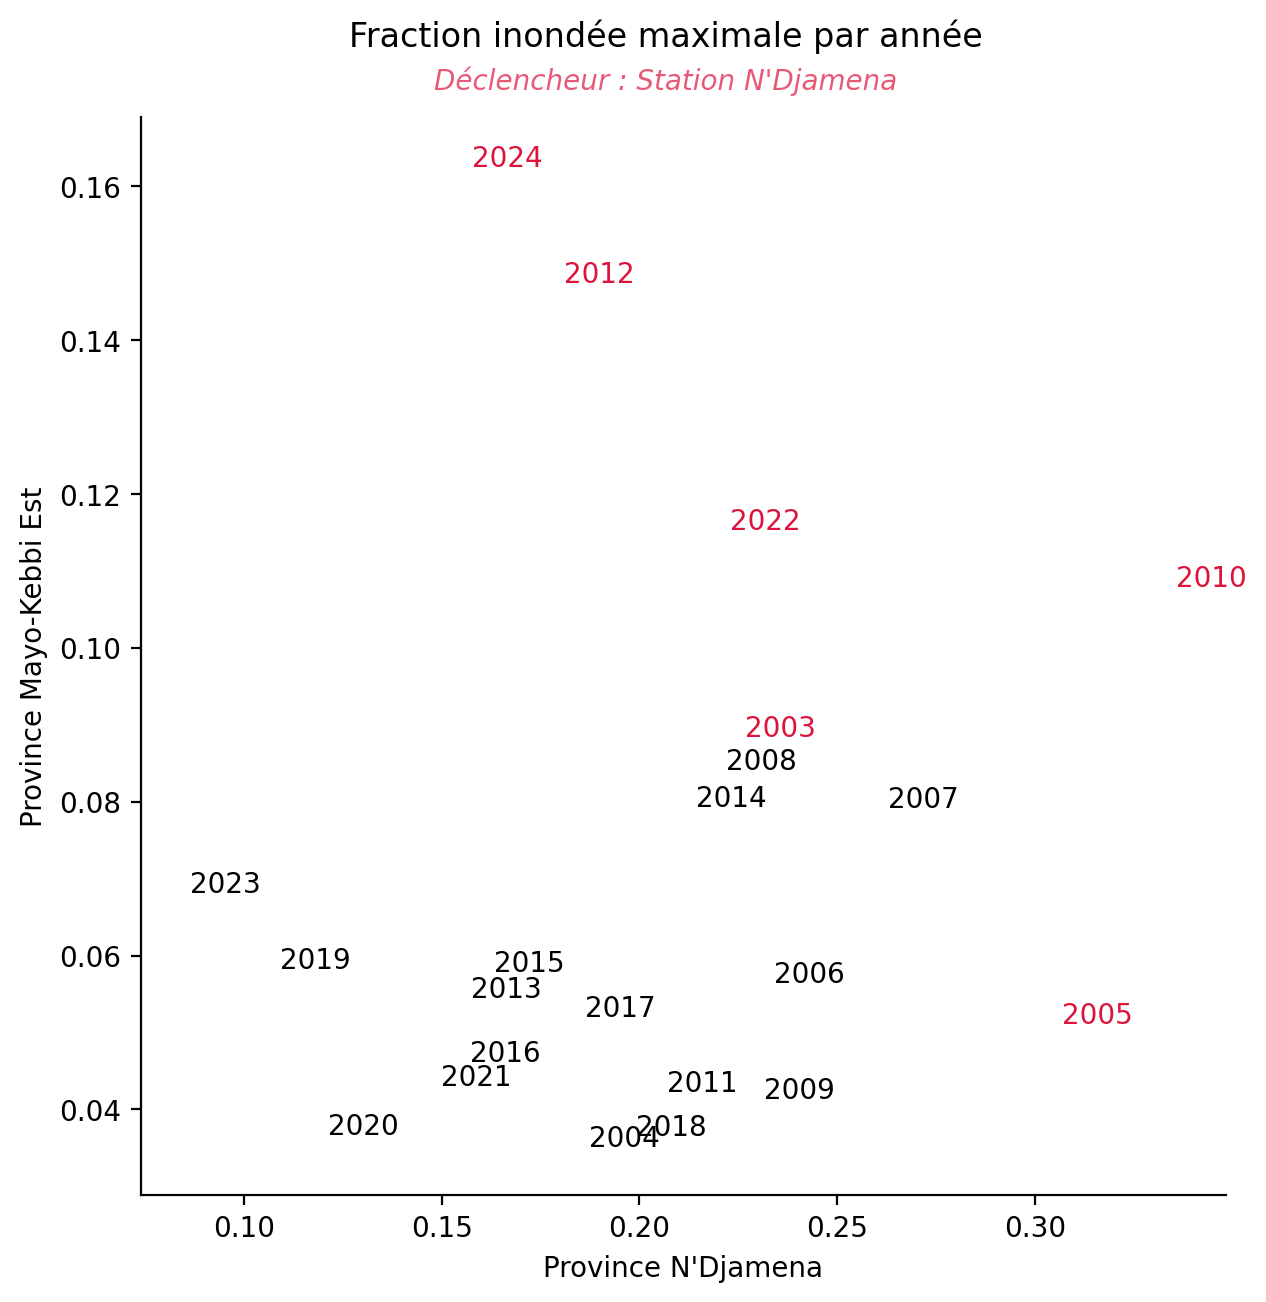

In [434]:
fig, ax = plot_exposure_trig("n_only_trig", "Station N'Djamena")

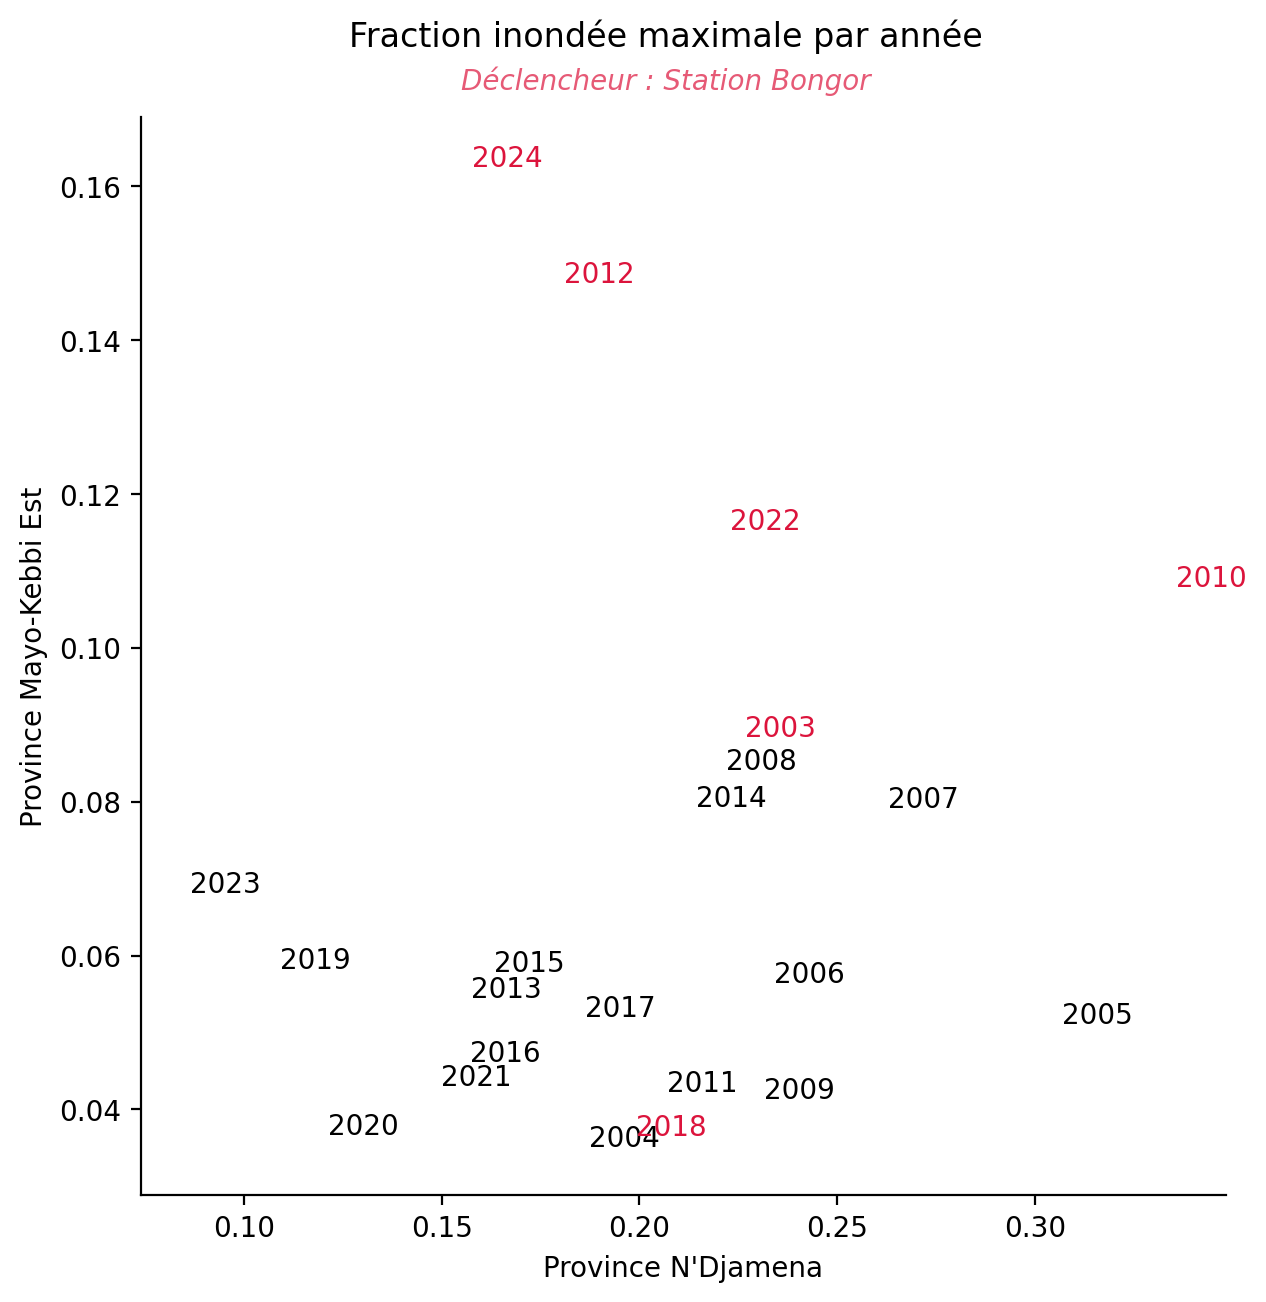

In [435]:
fig, ax = plot_exposure_trig("b_only_trig", "Station Bongor")

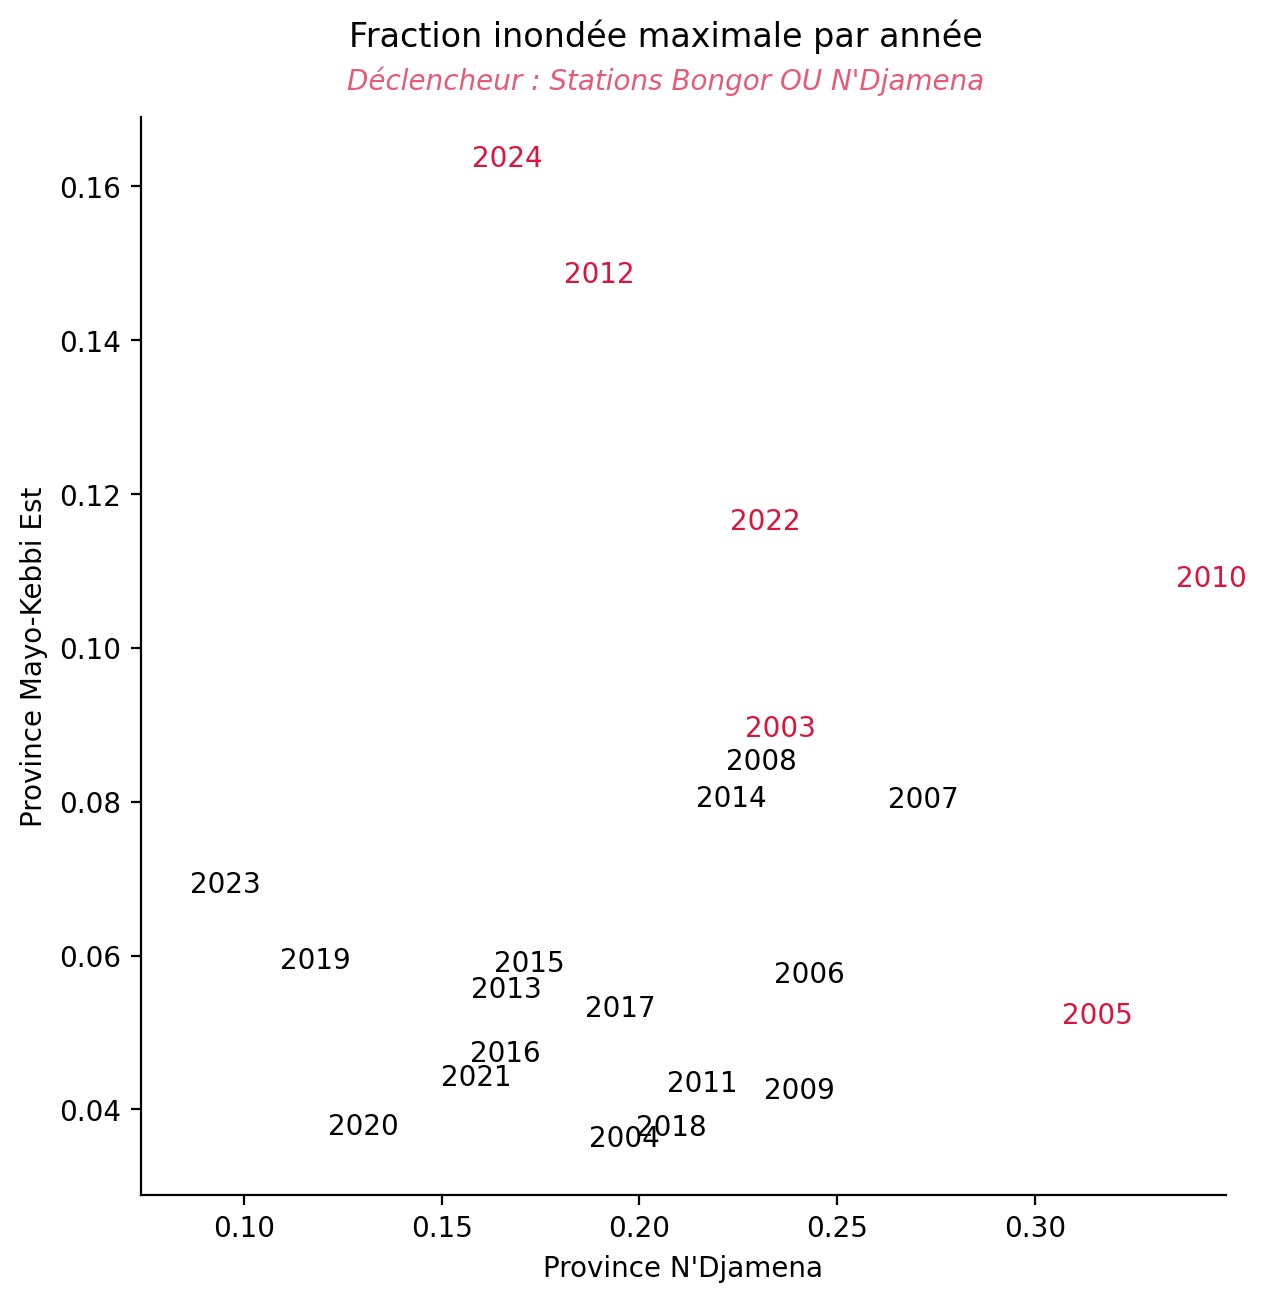

In [436]:
fig, ax = plot_exposure_trig("or_trig", "Stations Bongor OU N'Djamena")

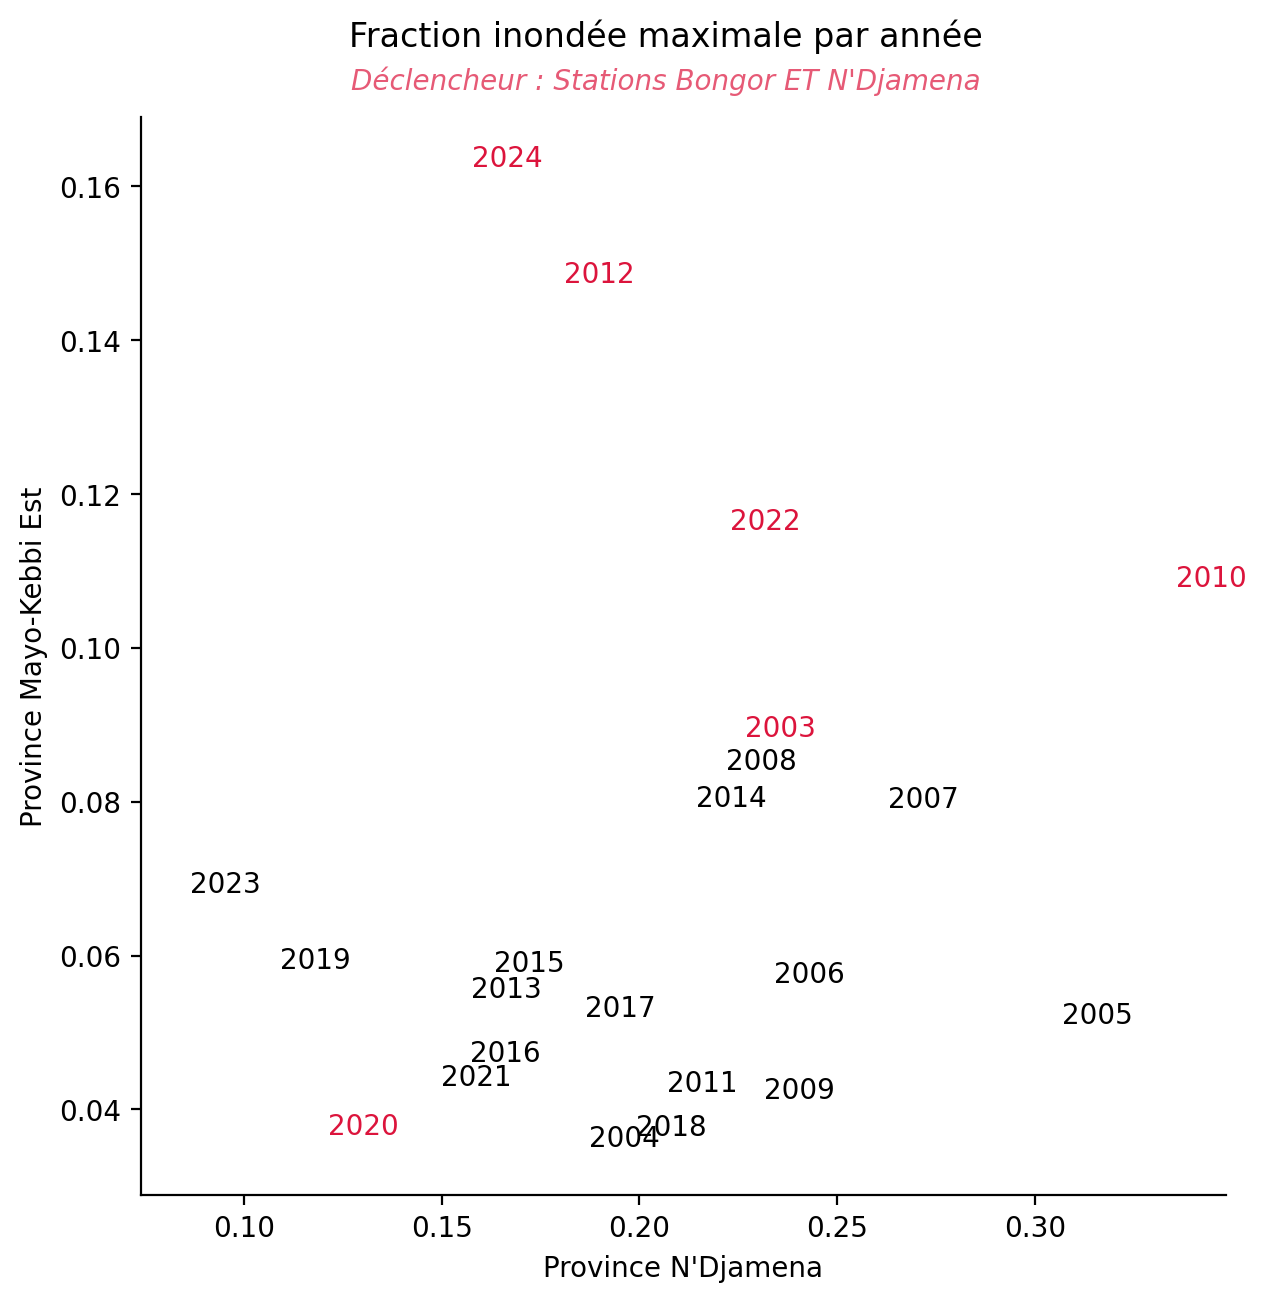

In [437]:
fig, ax = plot_exposure_trig("and_trig", "Stations Bongor ET N'Djamena")

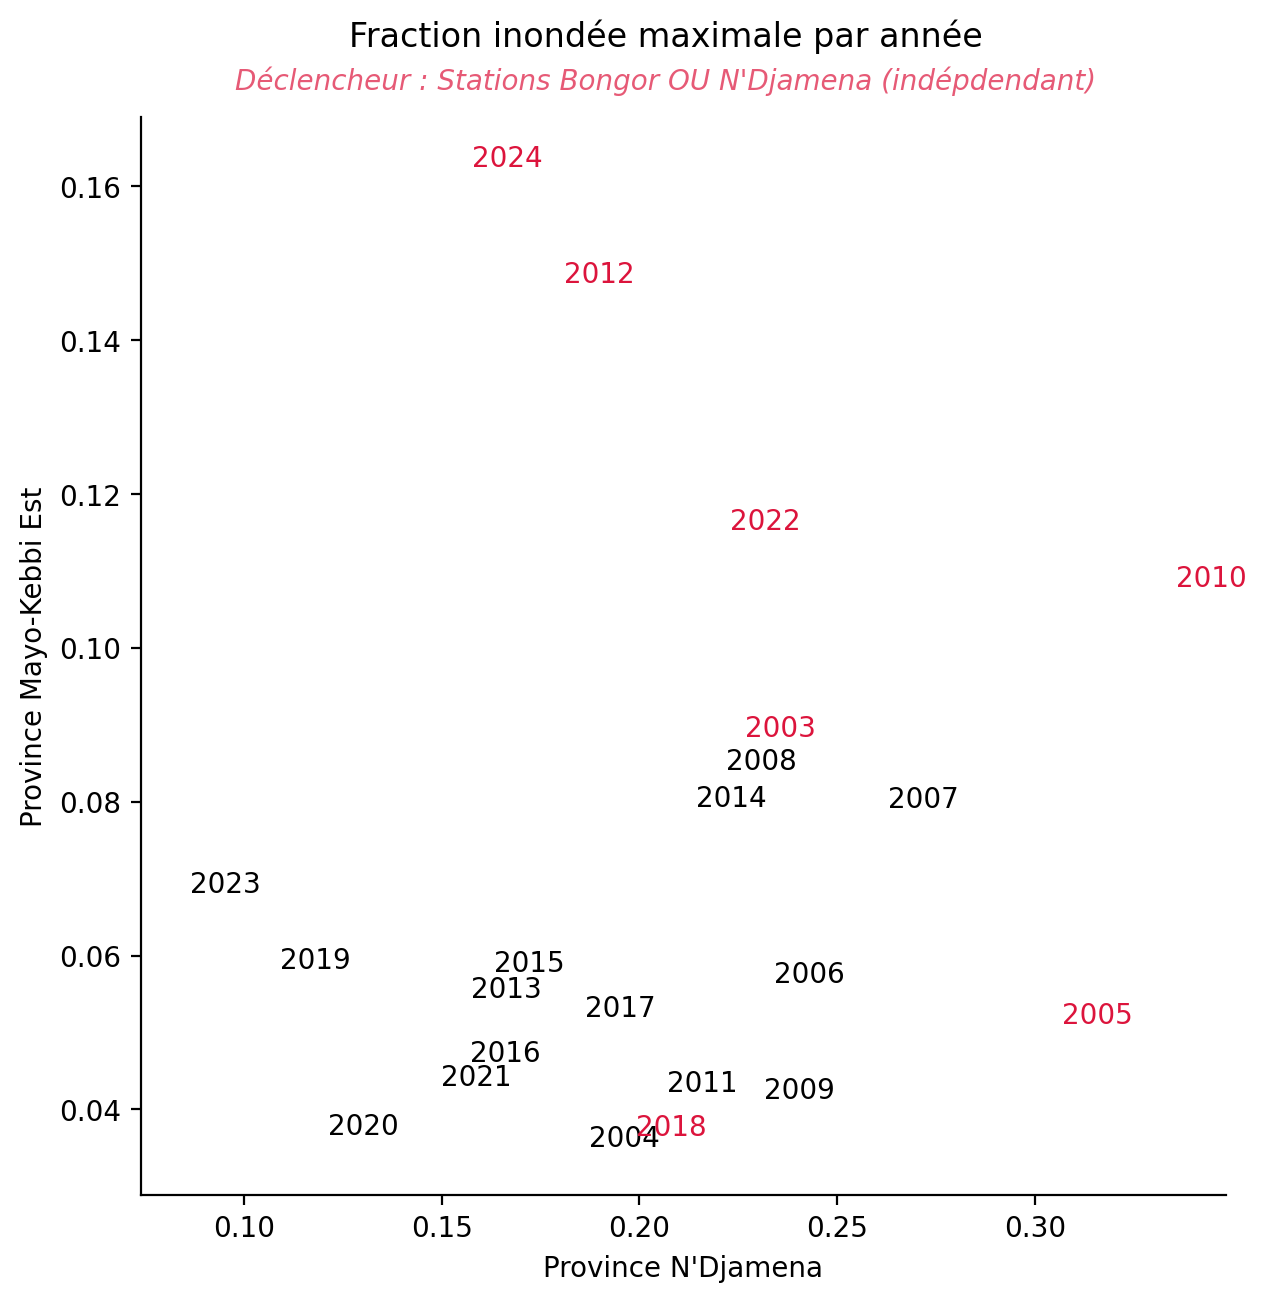

In [438]:
fig, ax = plot_exposure_trig(
    "indep_trig", "Stations Bongor OU N'Djamena (indépdendant)"
)

In [62]:
df_fs_peaks.sort_values("mean", ascending=False)

,valid_date,mean
26,2024,0.198390
14,2012,0.158322
0,1998,0.144514
3,2001,0.143453
24,2022,0.132774
12,2010,0.112130
1,1999,0.097005
16,2014,0.091496
10,2008,0.086833
5,2003,0.085028


In [59]:
df_peaks.merge(
    df_fs_peaks.rename(columns={"valid_date": "time", "mean": "fs_mean"}),
    how="left",
).corr()

,time,dis24_b,dis24_n,fs_mean
time,1.000000,0.146744,-0.224891,-0.002811
dis24_b,0.146744,1.000000,0.829336,0.699120
dis24_n,-0.224891,0.829336,1.000000,0.651233
fs_mean,-0.002811,0.699120,0.651233,1.000000


In [60]:
df_peaks

,time,dis24_b,dis24_n
0,2003,1860.046875,6072.0000
1,2004,1292.375000,2338.4140
2,2005,1628.164062,4930.1953
3,2006,1645.242188,3277.3750
4,2007,1491.601562,3096.8672
5,2008,1275.125000,1808.2734
6,2009,1150.062500,1495.7578
7,2010,2258.960938,6714.9453
8,2011,1349.304688,2377.5781
9,2012,2156.062500,5551.9844
